# Job Market Salary Analysis (2020–2025)
Analysis of Data Science job salaries across years, locations, experience levels, and company sizes

## 1. Import Libraries and Setup

Import all required packages and configure display options.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', 50)

## 2. Data Loading and Initial Inspection

Load the dataset from CSV file.

In [2]:
# Load the data
df = pd.read_csv("./Data/DataScience_salaries_2025.csv")  

In [3]:
# Quick preview of first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


In [4]:
# Basic information about columns, types and non-null counts
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93597 entries, 0 to 93596
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           93597 non-null  int64 
 1   experience_level    93597 non-null  object
 2   employment_type     93597 non-null  object
 3   job_title           93597 non-null  object
 4   salary              93597 non-null  int64 
 5   salary_currency     93597 non-null  object
 6   salary_in_usd       93597 non-null  int64 
 7   employee_residence  93597 non-null  object
 8   remote_ratio        93597 non-null  int64 
 9   company_location    93597 non-null  object
 10  company_size        93597 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.9+ MB


In [5]:
# Summary statistics of numeric columns
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,work_year,salary,salary_in_usd,remote_ratio
count,93597.000000,9.359700e+04,93597.000000,93597.000000
mean,2024.086434,1.623541e+05,157547.696774,21.455816
std,0.641449,2.221425e+05,73649.113729,40.954704
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.062600e+05,106250.000000,0.000000
50%,2024.000000,1.470000e+05,146232.000000,0.000000
75%,2024.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


## 3. Data Quality Check – Missing Values
Check missing values in dataset.

In [6]:
# Check missing values per column
print("\nMissing Values:")
missing_values= df.isna().sum()
print(missing_values)


Missing Values:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


## 4. Data Quality Check – Duplicate Rows
Check duplicate rows.

In [7]:
# Count duplicate rows (entire row identical)
duplicate_values = df.duplicated().sum()
print("Total duplicate values: ", duplicate_values)

Total duplicate values:  46960


### 4.1 Inspect duplicate rows

In [8]:
dup_row = df[df.duplicated(keep = False)]
print("\nDuplicate rows:")
print(dup_row.sort_values(['salary_in_usd']).head(10))


Duplicate rows:
       work_year experience_level employment_type      job_title   salary  \
10443       2025               EN              FT       Engineer   504000   
10445       2025               EN              FT       Engineer   504000   
33413       2024               MI              FT  AI Specialist  5400000   
33412       2024               MI              FT  AI Specialist  5400000   
67567       2024               MI              FT   Data Analyst    16000   
21020       2024               EN              FT   Data Analyst    14400   
68241       2024               EN              FT   Data Analyst    14400   
67568       2024               MI              FT   Data Analyst    16000   
65566       2024               MI              FT   Data Analyst    16000   
65565       2024               MI              FT   Data Analyst    16000   

      salary_currency  salary_in_usd employee_residence  remote_ratio  \
10443             TWD          15281                 TW       

### 4.2 Creating a Clean Dataset

After identifying duplicate rows, a clean version of the dataset was created by removing duplicates.
This ensures that each record is unique and prevents duplicated entries from skewing salary analysis.

The number of rows before and after cleaning was compared to verify how many duplicate records were removed.

In [9]:
df_clean = df.drop_duplicates()
print("Original dataframe: ", len(df))
print("New dataframe: ", len(df_clean))
print("Number of rows removed: ", len(df) - len(df_clean))

Original dataframe:  93597
New dataframe:  46637
Number of rows removed:  46960


## 5. Salary Summary Statistics
Quick overview of key salary metrics in USD.

In [10]:
#Salary sanity - min, max, median,25 and 75 percentile
salary_summary = {'min_salary': df_clean["salary_in_usd"].min(),
                  'max_salary': df_clean["salary_in_usd"].max(),
                  'median_salary': df_clean["salary_in_usd"].median(),
                  'percentile_25': df_clean['salary_in_usd'].quantile(0.25), 
                  'percentile_75': df_clean['salary_in_usd'].quantile(0.75)
                  }


print("\nSalary Summary(in USD):")
for key, values in salary_summary.items():
    print(f"{key.capitalize().replace('_',' ')} : {values}")


Salary Summary(in USD):
Min salary : 15000
Max salary : 800000
Median salary : 139100.0
Percentile 25 : 96400.0
Percentile 75 : 190500.0


### 5.1 Salary Outliers Analysis (Boxplot)

The boxplot helps identify:
- Median salary
- Interquartile range (middle 50%)
- Potential outliers (extreme high/low salaries)

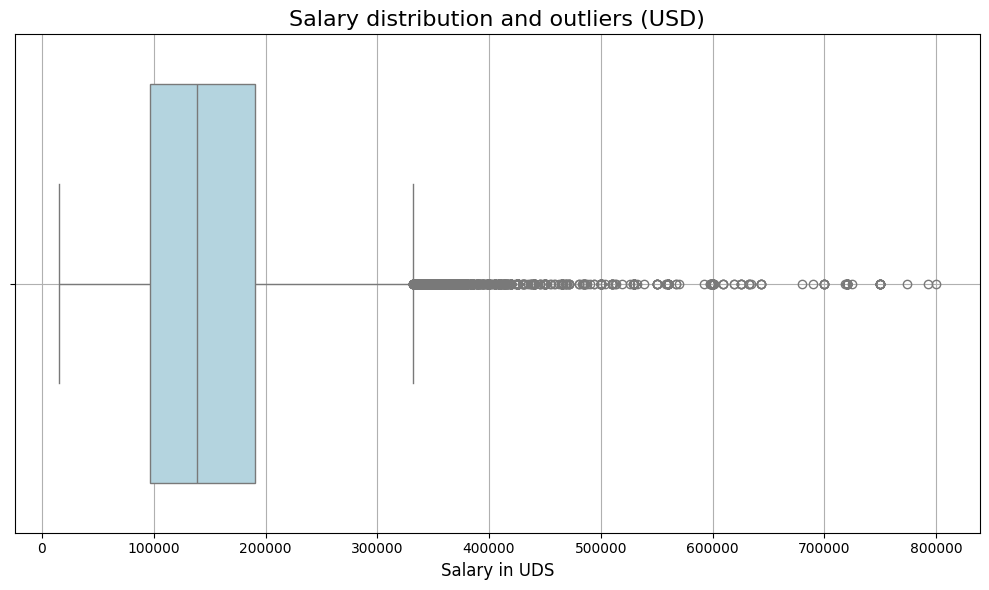

In [11]:
plt.figure(figsize = (10,6))
sns.boxplot(x=df_clean['salary_in_usd'], color = "lightblue")
plt.title("Salary distribution and outliers (USD)", fontsize=16)
plt.xlabel('Salary in UDS', fontsize = 12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusion:

This boxplot visualizes the distribution of salaries in USD across the dataset and highlights the presence of outliers.

The majority of salaries are concentrated within a relatively lower range, as indicated by the interquartile range (IQR).
However, several high-value outliers are observed on the upper end of the salary scale, extending far beyond the typical salary range.

These outliers likely represent senior-level roles, specialized positions, or employees working in high-paying regions or companies.
The right-skewed distribution suggests that while most professionals earn moderate salaries, a small number earn exceptionally high compensation.

## 6. Univariate Analysis

Univariate analysis examines the distribution of individual variables in the dataset.  
We will analyze key categorical variables: work year, experience level, job title, company size, and company location.

### 6.1 Year-wise Distribution

This analysis shows the number of job records available for each work year.
It helps understand how the dataset is distributed over time and whether certain years have more data coverage than others.

In [12]:
#Year wise distribution
year_count = df_clean['work_year'].value_counts()
print("\nYear wise distribution:")
print(year_count)


Year wise distribution:
work_year
2024    27686
2025    13013
2023     4536
2022     1113
2021      214
2020       75
Name: count, dtype: int64


### 6.2 Distribution by Experience Level

This section analyzes the distribution of roles across different experience levels.
It provides insight into which experience levels are most common in the dataset and helps identify whether the market is dominated by entry-level, mid-level, or senior roles.

In [13]:
experience_count = df_clean['experience_level'].value_counts()
print("Experience level distribution:")
print(experience_count)

Experience level distribution:
experience_level
SE    24749
MI    15049
EN     5391
EX     1448
Name: count, dtype: int64


### 6.3 Distribution by Job Title

This analysis displays the most common job titles in the dataset.
It helps identify which roles appear most frequently and gives an overview of demand for different data-related positions.

In [14]:
title_count = df_clean['job_title'].value_counts().head(10)
print("\nTop 10 Most Common Job Title:")
print(title_count)


Top 10 Most Common Job Title:
job_title
Data Scientist               5392
Data Engineer                5134
Data Analyst                 4570
Software Engineer            3172
Engineer                     2712
Machine Learning Engineer    2688
Manager                      2171
Analyst                      1439
Research Scientist           1074
Analytics Engineer            947
Name: count, dtype: int64


### 6.4 Company size distribution

This analysis examines how job records are distributed across different company sizes.
It helps understand whether data-related roles are more common in small, medium, or large organizations and provides context for later salary comparisons by company size.

In [15]:
company_count = df_clean['company_size'].value_counts()
print("\nCompany Size Distribution:")
print(company_count)


Company Size Distribution:
company_size
M    45117
L     1310
S      210
Name: count, dtype: int64


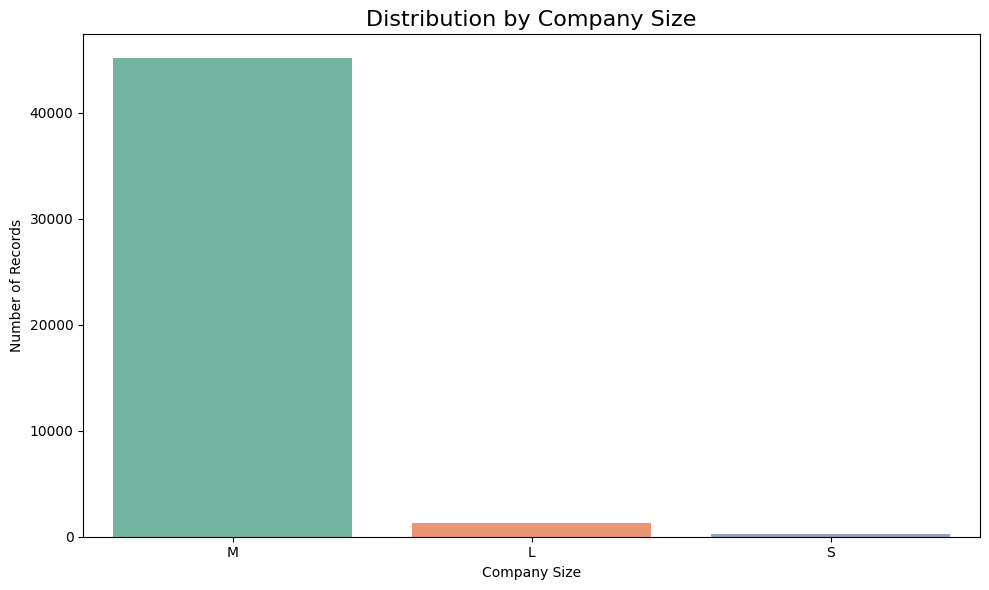

In [16]:
#Visual: Countplot for company size
plt.figure(figsize = (10,6))
sns.countplot(x = 'company_size', data=df_clean, hue= 'company_size', palette = "Set2")
plt.title("Distribution by Company Size", fontsize =16)
plt.xlabel('Company Size')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

###  Conclusion: 

The dataset is heavily dominated by *medium-sized companies*, which account for the majority of job records.
Small and large companies contribute significantly fewer observations in comparison.

This imbalance suggests that the job market data is more representative of employment trends in medium-sized organizations.
As a result, insights related to salary patterns and job roles may be more influenced by medium-sized companies than by small or large firms.

### 6.5 Company Location distribution

This section analyzes the top company locations present in the dataset.
It provides insight into which countries or regions have the highest number of data-related job roles and highlights geographical concentration in the job market.

In [17]:
location_count = df_clean['company_location'].value_counts().head(10)
print("\nTop 10 Company Location:")
print(location_count)


Top 10 Company Location:
company_location
US    39512
CA     2634
GB     1875
AU      283
DE      245
FR      186
LT      181
NL      174
ES      140
IN      121
Name: count, dtype: int64


### 6.6 Remote work ratio

This analysis examines the distribution of remote work ratios in the dataset.
It shows how roles are split between on-site, hybrid, and fully remote positions and provides insight into the prevalence of remote work in the data job market.

In [18]:
remote_count = df_clean['remote_ratio'].value_counts()
print("\nRemote Work Ratio Distribution")
print(remote_count)


Remote Work Ratio Distribution
remote_ratio
0      34848
100    11493
50       296
Name: count, dtype: int64


## 7. Bivariate Analysis

Bivariate analysis explores the relationship between two variables.  
Here we examine how median salary changes over time, by experience level, and across popular job titles.

### 7.1 Median Salary Trend Over Years (Time Series)

This analysis calculates the median salary for each work year.
Using the median helps reduce the effect of outliers and provides a clearer view of overall salary trends over time.

In [19]:
#Calculate median salary per year
median_salary_by_year = df_clean.groupby('work_year')['salary_in_usd'].median().reset_index()

print("\nMedian Salary by Year:")
print(median_salary_by_year)


Median Salary by Year:
   work_year  salary_in_usd
0       2020        79833.0
1       2021        82528.0
2       2022       129300.0
3       2023       142200.0
4       2024       140000.0
5       2025       138500.0


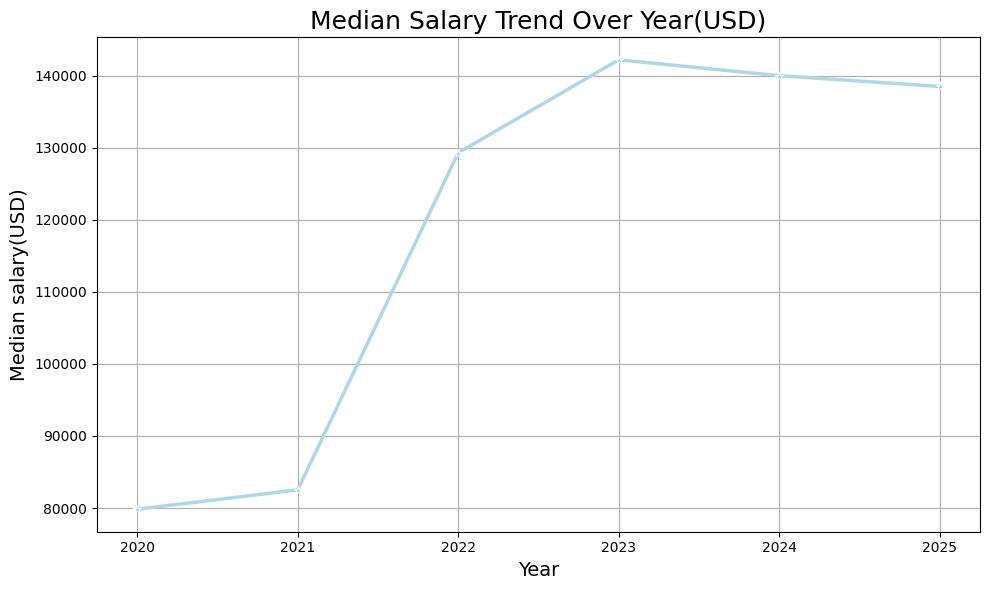

In [20]:
#Line plot for trend
plt.figure(figsize = (10, 6))
sns.lineplot(data= median_salary_by_year, x='work_year', y = 'salary_in_usd',
            marker = '*', linewidth=2.5, color ='lightblue')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Median salary(USD)", fontsize=14)
plt.title("Median Salary Trend Over Year(USD)", fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation:

- The median salary shows a *steady increase from 2020 to 2023*.
- The most significant growth occurs between *2021 and 2022*, indicating a sharp rise in market demand.
- After peaking around *2023, the median salary shows a **slight decline or stabilization* in 2024 and 2025.
- Overall salary levels in later years remain *significantly higher than in 2020*.

### Conclusion:

The overall median salary trend indicates strong growth in the tech and data job market over the years, particularly after 2021.
Although there is a slight slowdown in recent years, salaries remain elevated compared to earlier periods.
This suggests that while the market may be stabilizing, long-term career prospects and compensation levels in data and technology roles remain strong.

### 7.2 Median Salary by Experience Level

This analysis compares median salaries across different experience levels.
Using the median helps reduce the influence of extreme salary values and highlights how compensation increases as professionals gain more experience.

In [21]:
#Calculate median salary by experience level
median_salary_by_experience = df_clean.groupby('experience_level')['salary_in_usd'].median().reset_index()

print("\nMedian Salary by Experience Level (USD):")
print(median_salary_by_experience)


Median Salary by Experience Level (USD):
  experience_level  salary_in_usd
0               EN        85428.0
1               EX       188640.0
2               MI       123800.0
3               SE       157267.0


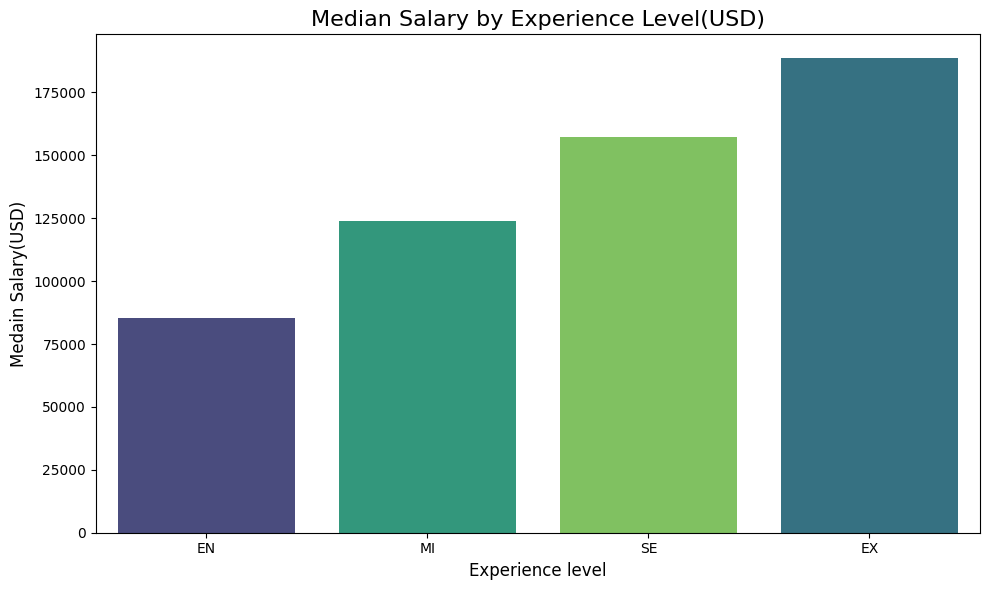

In [22]:
#Bar plot
plt.figure(figsize=(10,6))
sns.barplot(data= median_salary_by_experience,
            x='experience_level' ,
            y='salary_in_usd',
            order = ['EN','MI', 'SE', 'EX'],
            hue='experience_level',
            palette ="viridis")
plt.xlabel("Experience level", fontsize=12)
plt.ylabel("Medain Salary(USD)", fontsize=12)
plt.title("Median Salary by Experience Level(USD)", fontsize=16)
plt.tight_layout()
plt.show()

### Observation:
- Median salary increases consistently with each higher experience level.
- Entry-level (EN) roles have the lowest median salary.
- Executive-level (EX) roles command the highest median salary, with a significant jump compared to senior-level positions.
- The salary gap widens noticeably at higher experience levels.

### Conclusion:

Experience level plays a major role in determining compensation.
There is a strong positive relationship between experience level and median salary.
This indicates that long-term career growth, continuous upskilling, and progression into senior or executive roles significantly enhance earning potential.

### 7.3 Median Salary Comparison – Popular Job Titles

This analysis compares median salaries across selected popular job titles, including Data Scientist, Data Analyst, Data Engineer, and Software Engineer.

In [23]:
#Selecting popular job titles
selected_titles = ['Data Scientist','Data Analyst','Data Engineer','Software Engineer']
df_titles = df_clean[df_clean['job_title'].isin(selected_titles)]

#Group and calculate median for popular job titles
median_salary_by_title = df_titles.groupby('job_title')['salary_in_usd'].median().reset_index()

print("\nMedian Salary by Selected Job Title (USD):")
print(median_salary_by_title)


Median Salary by Selected Job Title (USD):
           job_title  salary_in_usd
0       Data Analyst        96000.0
1      Data Engineer       137000.0
2     Data Scientist       143225.0
3  Software Engineer       170067.5


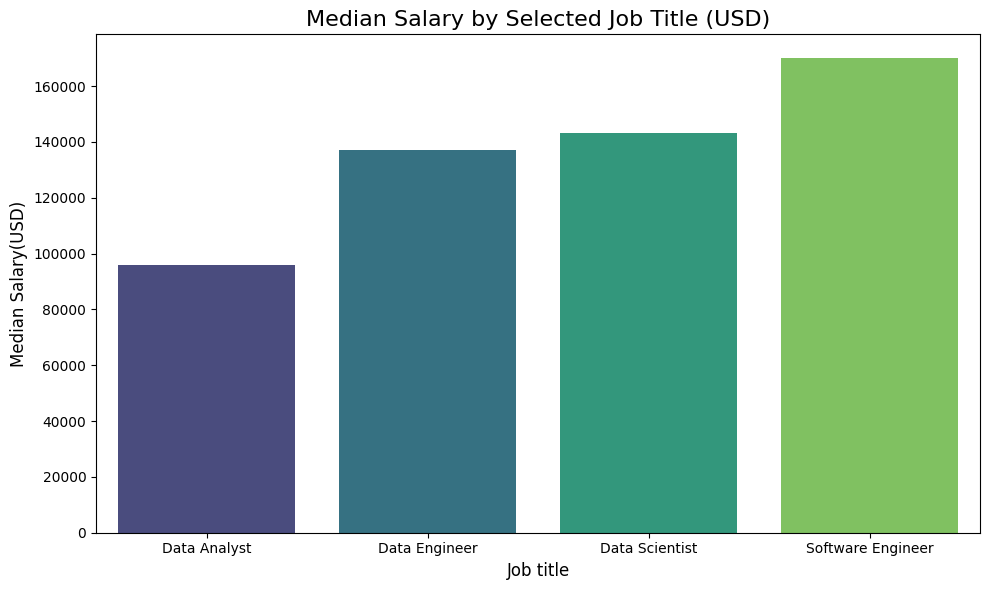

In [24]:
#Bar plot 
plt.figure(figsize=(10,6))
sns.barplot(data=median_salary_by_title,
            x='job_title',
            y='salary_in_usd',
            hue='job_title',
            palette ='viridis')
plt.xlabel("Job title",fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median Salary by Selected Job Title (USD)", fontsize=16)
plt.tight_layout()
plt.show()

### Observation:
- Software Engineers have the highest median salary among the selected job titles.
- Data Scientists and Data Engineers earn higher median salaries compared to Data Analysts.
- Data Analysts show the lowest median salary, indicating an entry to mid-level compensation range relative to other roles.

###  Conclusion:
The variation in median salaries reflects differences in skill requirements, technical complexity, and market demand.
Job titles with higher technical depth and broader system responsibilities command higher median salaries.
This suggests that professionals aiming for higher compensation may benefit from upskilling toward engineering-heavy or advanced data science roles.

### 7.4 Median Salary by Company Size

This analysis examines how company size impacts median salary levels.
Companies are categorized as:
- Small (S)
- Medium (M)
- Large (L)

Median salary is calculated for each company size to understand whether larger organizations tend to offer higher compensation.

In [25]:
#calculate median salary by company size
median_salary_by_size =df_clean.groupby('company_size')['salary_in_usd'].median().reset_index()

print("\nMedian Salary by Company Size(USD):")
print(median_salary_by_size)


Median Salary by Company Size(USD):
  company_size  salary_in_usd
0            L       127300.0
1            M       140000.0
2            S        75324.0


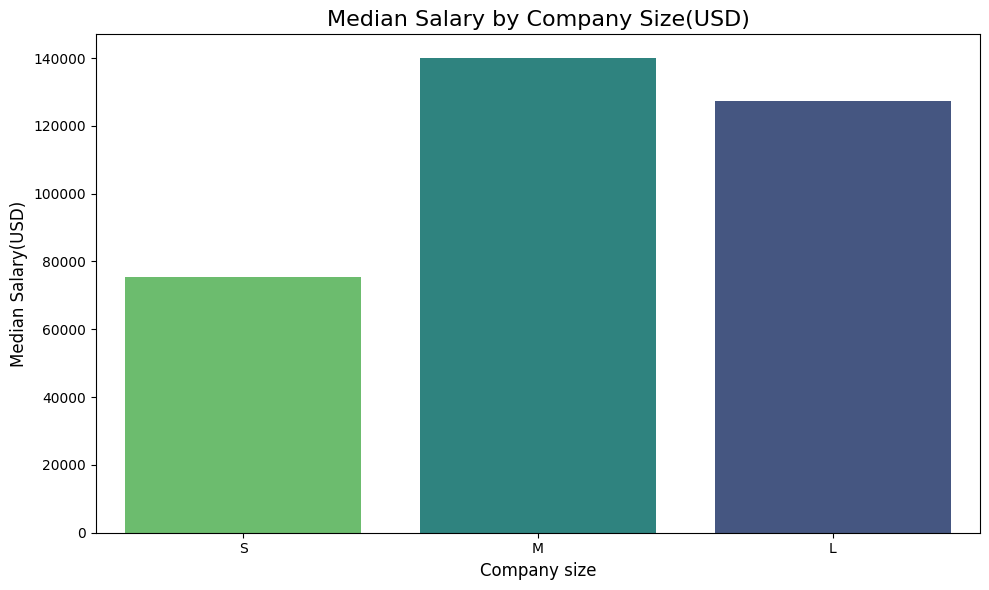

In [26]:
#Bar plot
plt.figure(figsize=(10,6))
size_order = ['S','M','L']
sns.barplot(data=median_salary_by_size ,
            x='company_size',
            y='salary_in_usd',
            order=size_order,
            hue= 'company_size',
            palette ='viridis')
plt.xlabel("Company size", fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median Salary by Company Size(USD)", fontsize=16)
plt.tight_layout()
plt.show()

### Observation:
- Small-sized companies (S) offer the lowest median salaries.
- Medium-sized companies (M) provide the highest median salary among the three categories.
- Large companies (L) offer competitive salaries but slightly lower than medium-sized companies.


### Conclusion:
Median salary varies by company size, with medium-sized companies offering the highest pay on average.
This suggests that professionals seeking higher immediate compensation may find better opportunities in medium-sized firms, while large companies may compensate through non-monetary benefits and long-term growth.

### 7.5 Median Salary by Company Location (Major Countries)

This analysis compares the median salary (USD) offered by companies across major countries:
- United States (US)
- Canada (CA)
- United Kingdom (GB)
- Australia (AU)
- Germany (DE)

Only these locations are selected to ensure a fair comparison among countries with sufficient data points.  
Median salary is used to minimize the effect of extreme salary values.

In [27]:
# Select major countries
selected_location = ['US', 'CA', 'GB', 'AU', 'DE']
df_locations = df_clean[df_clean['company_location'].isin(selected_location)]

#Calculate median salary by company location
median_salary_by_location = df_locations.groupby('company_location')['salary_in_usd'].median().reset_index()

print("\nMedian Salary by Company Location")
print(median_salary_by_location)



Median Salary by Company Location
  company_location  salary_in_usd
0               AU       114231.0
1               CA       119668.0
2               DE        84111.0
3               GB        75949.0
4               US       147000.0


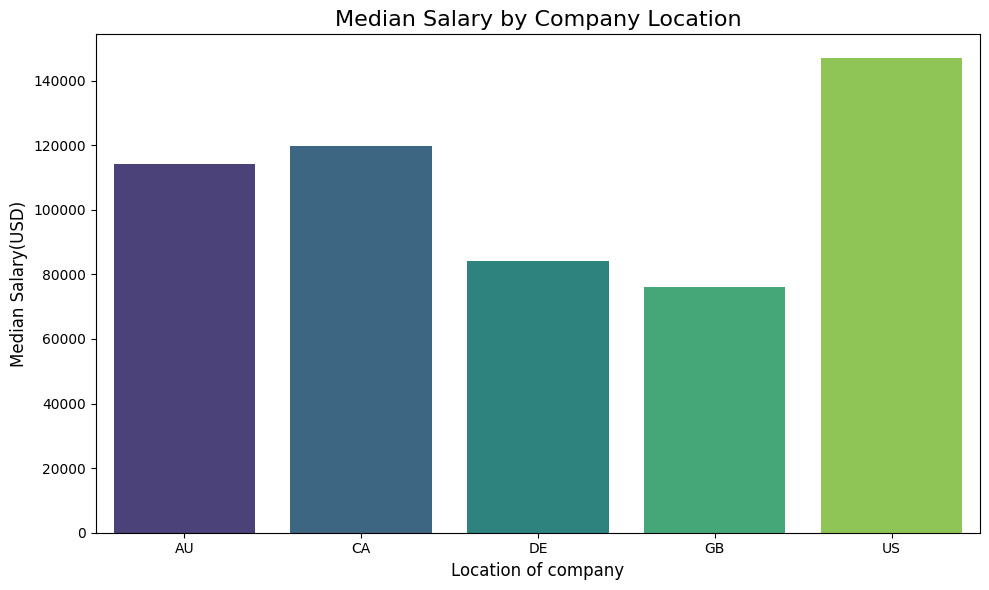

In [28]:
#Bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=median_salary_by_location,
            x='company_location', 
            y='salary_in_usd',
            hue='company_location',
            palette ='viridis')
plt.xlabel("Location of company", fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median Salary by Company Location", fontsize=16)
plt.tight_layout()
plt.show()

### Observation:
- The United States (US) has the highest median salary among all listed company locations.
- Canada (CA) and Australia (AU) also offer relatively high median salaries, though lower than the US.
- Germany (DE) and the United Kingdom (GB) have noticeably lower median salaries compared to North America and Australia.

### Conclusion:
There is a clear regional variation in median salaries, with North America—particularly the US—offering the highest compensation.
This suggests that geographic location plays a crucial role in salary expectations, and professionals seeking higher pay may benefit from targeting roles in high-paying regions or considering remote opportunities tied to these markets.

## 8. Multivariate Analysis
Multivariate analysis examines the combined effect of multiple variables on salary rather than analyzing each factor independently.  
It helps uncover deeper patterns and interactions between factors such as experience level, job title, company size, and location

### 8.1 Combined Effect of Experience Level and Job Title on Salary Distribution

This analysis explores how salary varies jointly with job title and experience level.
The median salary (USD) is calculated for each combination of:
- Job Title
- Experience Level (EN, MI, SE, EX)

Using a grouped bar chart allows direct comparison of salary progression across experience levels within each job role.

In [29]:
#Group by both job title and experience level
median_salary_title_experience = df_titles.groupby(['job_title', 'experience_level'])['salary_in_usd'].median().reset_index()
print(median_salary_title_experience)

            job_title experience_level  salary_in_usd
0        Data Analyst               EN        81000.0
1        Data Analyst               EX       114880.0
2        Data Analyst               MI        88000.0
3        Data Analyst               SE       116700.0
4       Data Engineer               EN        84000.0
5       Data Engineer               EX       200000.0
6       Data Engineer               MI       116047.0
7       Data Engineer               SE       151500.0
8      Data Scientist               EN        86520.0
9      Data Scientist               EX       192018.5
10     Data Scientist               MI       121800.0
11     Data Scientist               SE       161000.0
12  Software Engineer               EN       111550.0
13  Software Engineer               EX       229993.0
14  Software Engineer               MI       155000.0
15  Software Engineer               SE       182312.0


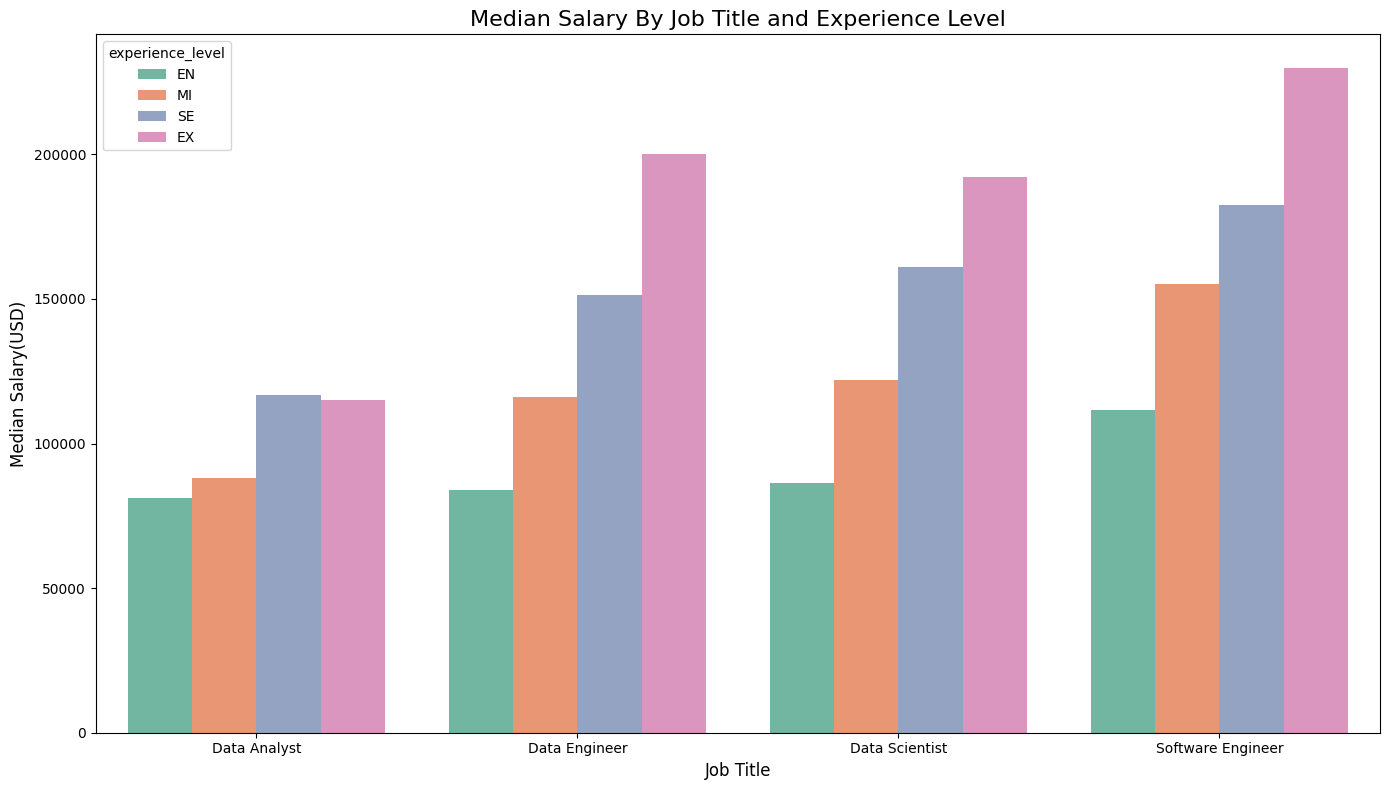

In [30]:
#Grouped bar plot(hue= experience level)
exp_order = ['EN','MI','SI','EX']
plt.figure(figsize=(14,8))
sns.barplot(
            data = median_salary_title_experience,
            x ='job_title',
            y='salary_in_usd',
            hue= 'experience_level',
            hue_order= ['EN', 'MI', 'SE', 'EX'],
            palette= 'Set2')
plt.xlabel("Job Title", fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median Salary By Job Title and Experience Level", fontsize=16)
plt.legend(title ='experience_level')
plt.tight_layout()
plt.show()

### Observation:

- Median salary increases consistently with *experience level* across all job titles.
- *Software Engineers* earn the highest salaries at every experience level, especially at the *Expert (EX)* level.
- *Data Scientists* earn more than *Data Analysts* at comparable experience levels.
- The salary gap between roles becomes more pronounced at *senior and expert levels*, indicating higher rewards for advanced skills and experience.
- Entry-level (EN) salaries across roles are relatively closer compared to mid and senior levels.

### Conclusion:

Experience level is a major driver of salary growth across all data and engineering roles.
Software Engineering roles show the steepest salary growth as experience increases, followed by Data Science roles.
This suggests that professionals can significantly improve earning potential by both *upskilling* and *progressing to higher experience levels*, especially in technically intensive roles.

### 8.2  Salary Variation Across Company Location and Company Size

This analysis examines how median salary (USD) varies across different company locations and company sizes simultaneously.
The data is grouped by:
- Company Location
- Company Size (Small, Medium, Large)

A grouped bar chart is used to compare salary levels across company sizes within each country, helping identify whether organization size influences compensation differently across regions.


In [31]:
#Group by both location and company size
median_salary_by_company = df_locations.groupby(['company_location', 'company_size'])['salary_in_usd'].median().reset_index()
print(median_salary_by_company)

   company_location company_size  salary_in_usd
0                AU            L        80919.0
1                AU            M       115171.0
2                AU            S       120000.0
3                CA            L        76782.5
4                CA            M       120000.0
5                CA            S        87738.0
6                DE            L        78467.0
7                DE            M        87058.5
8                DE            S        66666.0
9                GB            L        75471.5
10               GB            M        75949.0
11               GB            S        76958.0
12               US            L       145000.0
13               US            M       147000.0
14               US            S       112500.0


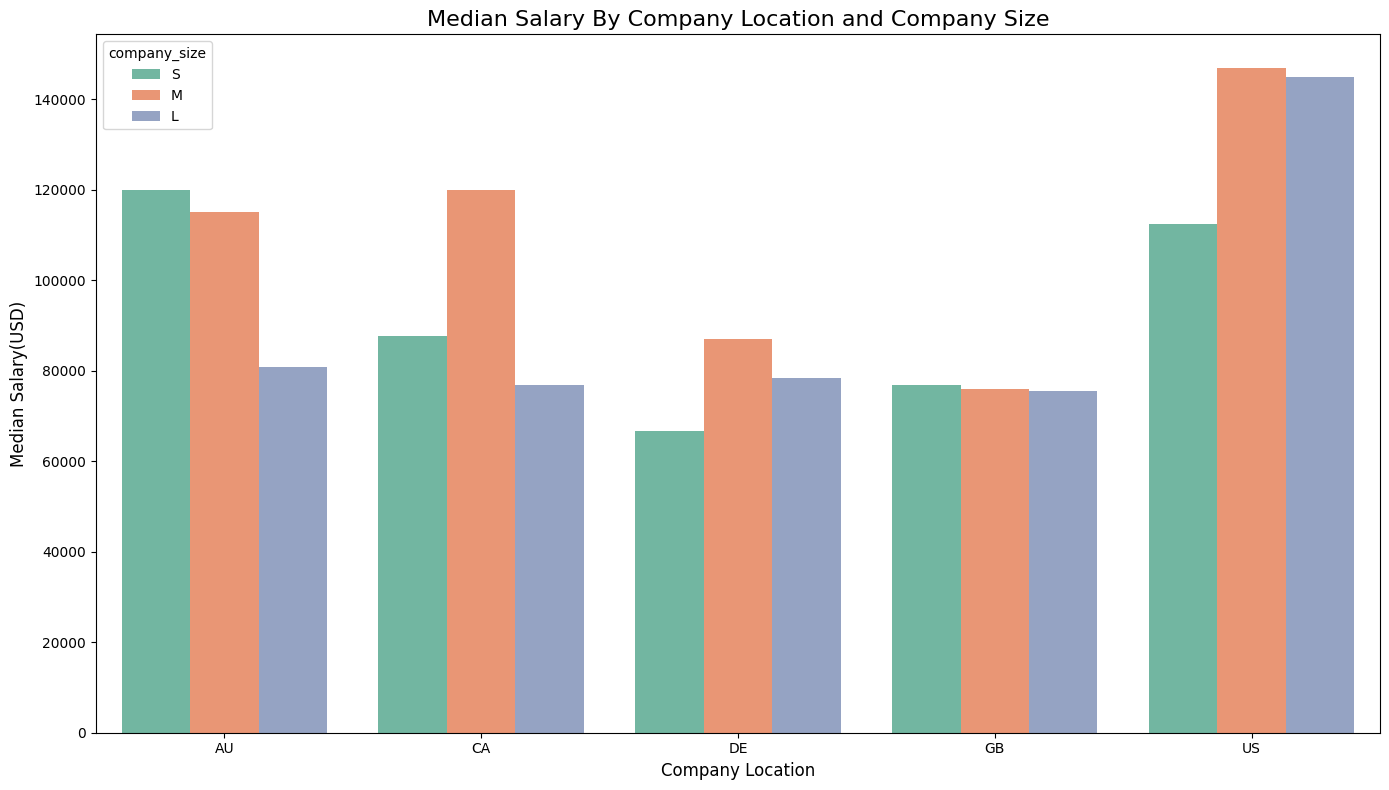

In [32]:
#Grouped bar plot(hue= company_size)
plt.figure(figsize=(14,8))
sns.barplot(
            data=median_salary_by_company, 
            x= 'company_location',
            y= 'salary_in_usd',
            hue = 'company_size',
            hue_order= ['S', 'M', 'L'],
            palette= 'Set2'
)
plt.xlabel("Company Location", fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median Salary By Company Location and Company Size", fontsize=16)
plt.legend(title ='company_size')
plt.tight_layout()
plt.show()

### Observation:
- In the US and Canada, medium-sized companies offer the highest median salaries compared to small and large companies.
- In Australia, small companies pay higher median salaries than medium and large companies.
- In Germany, medium-sized companies provide higher salaries, while small companies offer the lowest pay.
- In the UK, median salaries remain almost the same across all company sizes, showing very little variation.

###  Conclusion:

Median salary is influenced by both company location and company size.
While medium-sized companies generally offer higher salaries in several regions, this trend is not consistent across all countries.
This indicates that regional market conditions play a significant role, and compensation decisions should consider both geographic location and company size together rather than in isolation.

### 8.3 Impact of Company Location and Job Title on Median Salary

This analysis investigates how median salary (USD) varies across different company locations for selected job roles:
- Data Scientist  
- Data Analyst  
- Data Engineer  
- Software Engineer  

The data is grouped by company location and job title to understand how geographic factors interact with role-based compensation.

In [33]:
#Filter for selected titles in location subset
df_title_location = df_locations[df_locations['job_title'].isin(['Data Scientist','Data Analyst','Data Engineer','Software Engineer'])]

#Group by location and job title
median_salary_by_company_title = df_title_location.groupby(['company_location', 'job_title'])['salary_in_usd'].median().reset_index()
print(median_salary_by_company_title)

   company_location          job_title  salary_in_usd
0                AU       Data Analyst       110479.0
1                AU      Data Engineer       125223.0
2                AU     Data Scientist       108557.0
3                AU  Software Engineer       184500.0
4                CA       Data Analyst        90005.5
5                CA      Data Engineer       120950.0
6                CA     Data Scientist       133092.0
7                CA  Software Engineer       149750.0
8                DE       Data Analyst        62471.0
9                DE      Data Engineer        88421.0
10               DE     Data Scientist        75600.0
11               DE  Software Engineer        99999.5
12               GB       Data Analyst        59018.0
13               GB      Data Engineer        76558.5
14               GB     Data Scientist        82025.0
15               GB  Software Engineer       114203.0
16               US       Data Analyst       104000.0
17               US      Dat

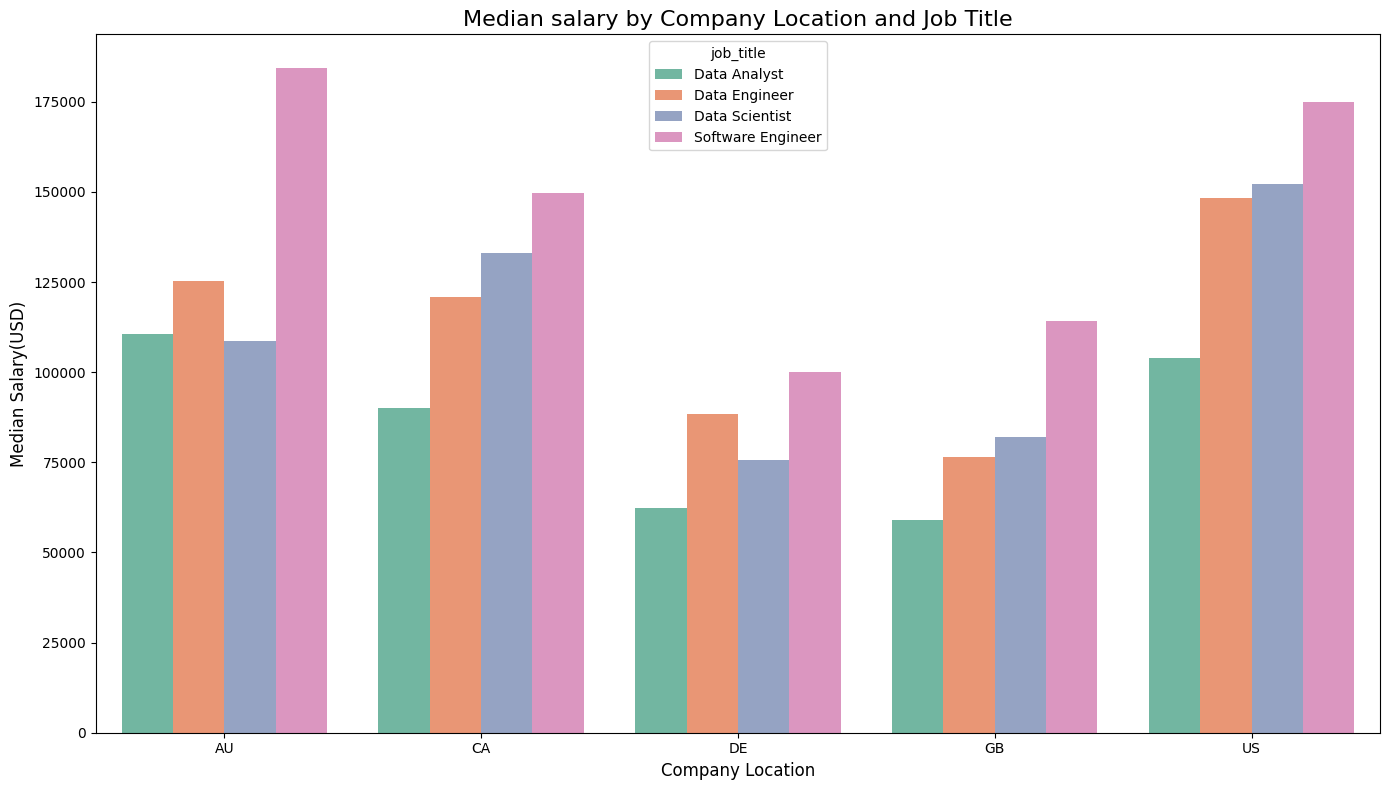

In [34]:
#Grouped bar plot(hue= company_size)
plt.figure(figsize=(14, 8))
sns.barplot(data = median_salary_by_company_title,
            x= 'company_location',
            y= 'salary_in_usd',
            hue = 'job_title',
            palette= 'Set2')
plt.xlabel("Company Location", fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median salary by Company Location and Job Title", fontsize=16)
plt.legend(title ='job_title')
plt.tight_layout()
plt.show()

### Observation:
- Across all locations, *Software Engineers* consistently have the highest median salaries.
- The *US* offers the highest salaries for all job roles compared to other countries.
- *Data Scientists* generally earn more than *Data Analysts* and are close to *Data Engineers* in most locations.
- *Germany (DE)* and *UK (GB)* show comparatively lower median salaries across all job titles.
- Salary gaps between job roles are widest in the *US and Australia*, indicating stronger role-based pay differentiation.

### Conclusion:

Median salary varies significantly based on both *job title and company location*.
Software engineering roles command the highest compensation globally, especially in the US.
Countries like the US and Australia provide stronger financial incentives for advanced technical roles, while European countries show more moderate and balanced pay structures.
This highlights that professionals should consider both *role specialization* and *geographic market* when evaluating salary potential.

### 8.4 Median Salary Trend Over Time by Job Title

This analysis examines how median salary (USD) has changed over time for different job titles.
The data is grouped by:
- Work Year
- Job Title

A year-wise comparison helps identify salary growth trends and differences in compensation progression across job roles.

In [35]:
#Group by year and job title
median_salary_by_time_role = df_titles.groupby(['work_year', 'job_title'])['salary_in_usd'].median().reset_index()
print(median_salary_by_time_role)

    work_year          job_title  salary_in_usd
0        2020       Data Analyst        59949.5
1        2020      Data Engineer        74130.0
2        2020     Data Scientist        76958.0
3        2021       Data Analyst        73393.0
4        2021      Data Engineer        86264.0
5        2021     Data Scientist        86369.0
6        2022       Data Analyst       105000.0
7        2022      Data Engineer       135000.0
8        2022     Data Scientist       136994.0
9        2023       Data Analyst       103600.0
10       2023      Data Engineer       139500.0
11       2023     Data Scientist       155600.0
12       2024       Data Analyst        95450.0
13       2024      Data Engineer       139100.0
14       2024     Data Scientist       144250.0
15       2024  Software Engineer       170000.0
16       2025       Data Analyst        93724.0
17       2025      Data Engineer       134600.0
18       2025     Data Scientist       136301.0
19       2025  Software Engineer       1

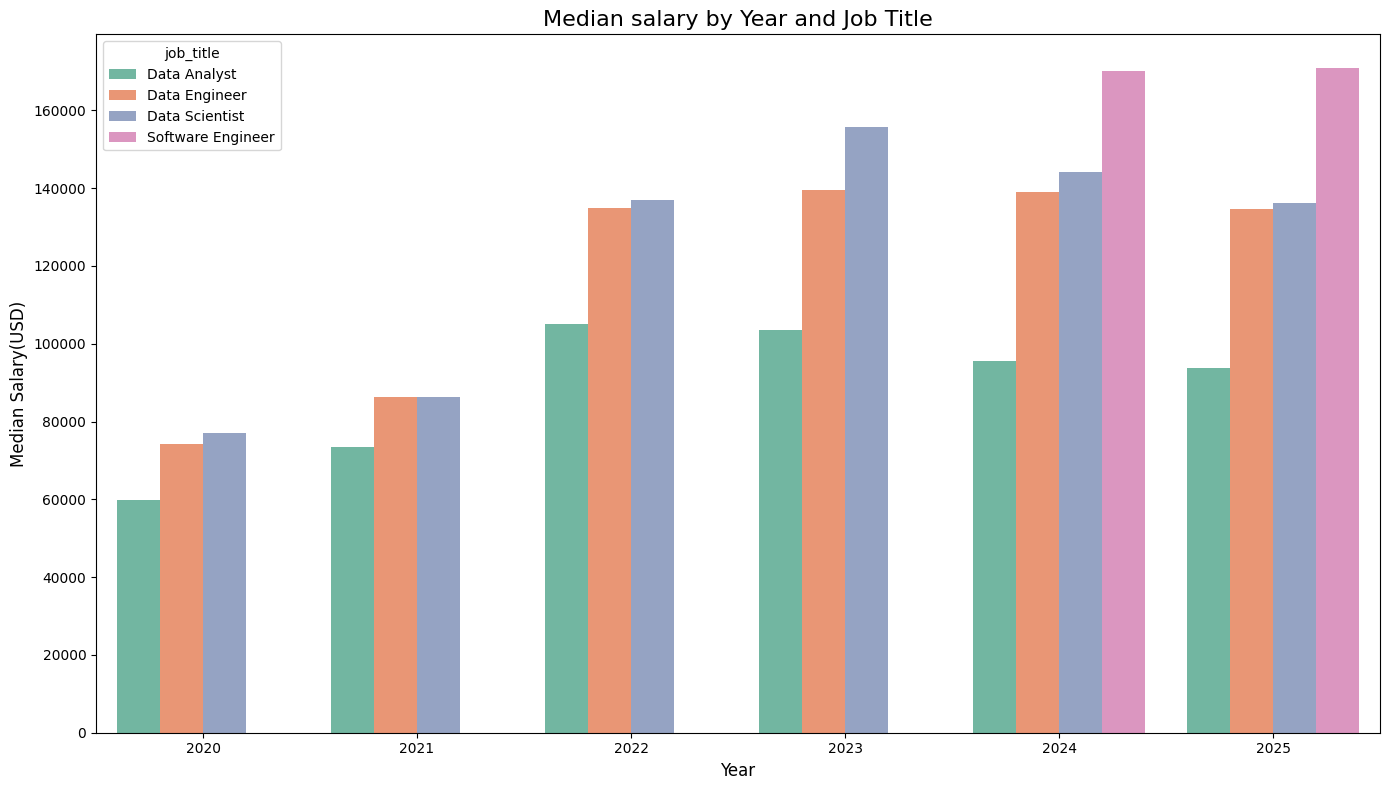

In [36]:
#Groupd bar plot
plt.figure(figsize=(14, 8))
sns.barplot(data= median_salary_by_time_role,
            x = 'work_year',
            y = 'salary_in_usd',
            hue = 'job_title',
            palette= 'Set2')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Median Salary(USD)", fontsize=12)
plt.title("Median salary by Year and Job Title", fontsize=16)
plt.legend(title ='job_title')
plt.tight_layout()
plt.show()

### Observation:

- Median salaries for all job titles show a *general upward trend from 2020 to 2025*.
- *Software Engineers* consistently have the highest median salary in recent years, especially from 2023 onward.
- *Data Scientists* and *Data Engineers* show strong salary growth, with noticeable increases after 2021.
- *Data Analysts* earn comparatively lower salaries, though steady growth is visible over time.
- The salary gap between roles widens after 2022, indicating increasing demand for advanced technical roles.

### Conclusion:

Median salaries across data and software roles have increased significantly over the years, reflecting growing demand in the tech industry.
Software Engineering and Data Science roles have benefited the most from this growth.
While Data Analyst roles show consistent improvement, higher-paying roles increasingly require advanced technical expertise.
Overall, the trend highlights strong long-term career prospects in data and software-related fields.